In [1373]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# MRS06 -- vytvorenie grafov do textu

In [1374]:
import numpy as np

import matplotlib.pyplot as plt

from scipy.integrate import odeint



import sys
sys.path.append('./figjobs/')

from figFcns_TeX import *


### O meraní prevodovej charakteristiky

In [1375]:
def fcn_rovniceKyvadla(x, t, u):
    
    x_1, x_2 = x

    m = 1
    l = 1
    g = 9.81
    beta = 2 * 1.0 * np.sqrt(g/l)

    dotx_1 = x_2
    dotx_2 = -(beta/(m*l**2)) * x_2 - (g/l) * np.sin(x_1) + (1/(m*l**2)) * u

    return [dotx_1, dotx_2]

In [1376]:
def fcn_simSch01(t_start, T_s, finalIndex, u_tabulka):

    #-----------------------------------------
    # casovy vektor

    t_log = np.zeros([finalIndex, 1])
    t_log[0,:] = t_start

    #-----------------------------------------
    # vektor stavu riadeneho systemu

    x_0 = np.array([0, 0])

    x_log = np.zeros([finalIndex, len(x_0)])
    x_log[0,:] = x_0

    #-----------------------------------------
    # vektor akcneho zasahu

    u_log = np.zeros([finalIndex, 1])

    for idx in range(u_log.shape[0]):
        lastValue = u_tabulka[:,1][u_tabulka[:,0] <= idx*T_s ][-1]
        u_log[idx] = lastValue

    #-----------------------------------------

    timespan = np.zeros(2)
    for idx in range(1, int(finalIndex)):

        #-------------------------------------
        # Riadeny system - simulacia (pomocou ODEsolvera)

        timespan[0] = t_log[idx-1,:]
        timespan[1] = t_log[idx-1,:] + T_s

        odeOut = odeint(fcn_rovniceKyvadla,
                        x_log[idx-1,:],
                        timespan,
                        args=(u_log[idx-1,0],)
                        )

        x_log[idx,:] = odeOut[-1,:]
        t_log[idx,:] = timespan[-1]

    # y bude umelo zasumeny vystup
    y = (x_log[:,0].reshape(-1,1)*180/np.pi) + ((np.random.rand(x_log[:,0].shape[0],1)-0.5)*2.5)


    return [t_log, x_log, u_log, y]

In [1377]:
u_tabulka = np.array([
    [0, 0.0],
    [10, 1.0],
    [20, 2.0],
    [30, 3.0],
    [40, 4.0],
    [50, 5.0],
    [60, 6.0],
    [70, 7.0],
    [80, 8.0],
    [95, 9.0],
    [110, 9.5],
    [135, 9.81],
    [180, 9.81],
    ])

In [1378]:
# Nastavenia simulacie

sim_t_start = 0
sim_t_final = u_tabulka[-1,0]
sim_T_s = 0.1
sim_finalIndex = int(((sim_t_final - sim_t_start)/sim_T_s) + 1)


# Simulacia
t_log, x_log, u_log, y = fcn_simSch01(sim_t_start, sim_T_s, sim_finalIndex, u_tabulka)

suroveData = np.hstack([t_log, y])

C:\Users\MT\AppData\Local\Temp\ipykernel_15524\2456142686.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  timespan[0] = t_log[idx-1,:]
C:\Users\MT\AppData\Local\Temp\ipykernel_15524\2456142686.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  timespan[1] = t_log[idx-1,:] + T_s


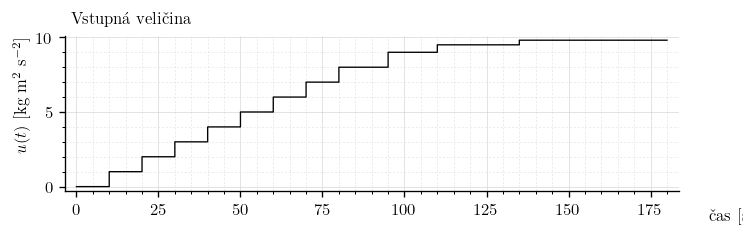

In [1379]:
MRSlabel = 'MRS06'

figNamePrefix = MRSlabel + '_figsc_01_'
figNameNum = 1
exec(open('./figjobs/MRS06_figsc_01.py', encoding='utf-8').read())

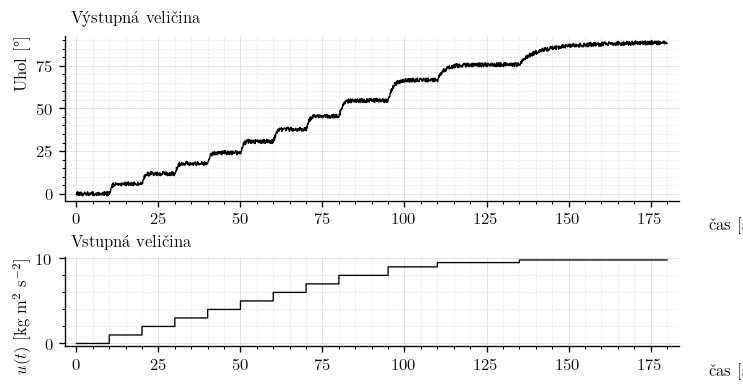

In [1380]:
figNamePrefix = MRSlabel + '_figsc_02_'
figNameNum = 2
exec(open('./figjobs/MRS06_figsc_02.py', encoding='utf-8').read())

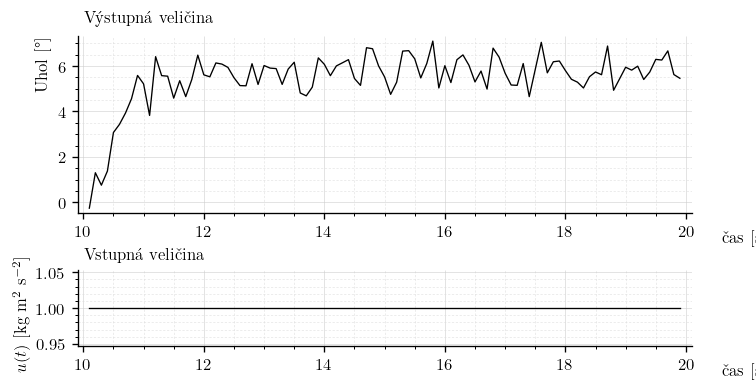

In [1381]:
tmpInterval = [ 
    u_tabulka[1][0] + (u_tabulka[2][0]-u_tabulka[1][0])*0,
    u_tabulka[2][0]
    ]

tmpMask = np.logical_and(suroveData[:,0]>tmpInterval[0], suroveData[:,0]<=tmpInterval[1])

figNamePrefix = MRSlabel + '_figsc_03_'
figNameNum = 3
exec(open('./figjobs/MRS06_figsc_03.py', encoding='utf-8').read())

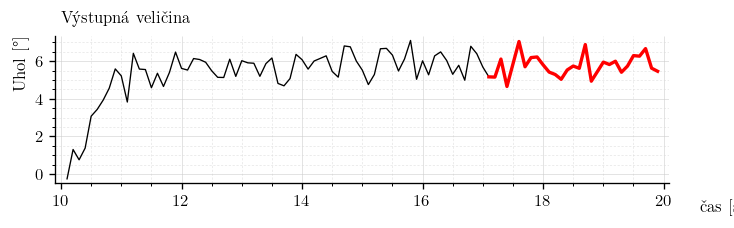

In [1382]:
ustVstup =  u_tabulka[1][1]
ustInterval = [
    u_tabulka[1][0] + (u_tabulka[2][0]-u_tabulka[1][0])*0.7,
    u_tabulka[2][0]
    ]

boolMaska = np.logical_and(suroveData[:,0]>ustInterval[0], suroveData[:,0]<=ustInterval[1])

ustVystCas = suroveData[boolMaska, 0]
ustVystHodnoty = suroveData[boolMaska, 1]

ustPriemer = np.mean(ustVystHodnoty)

figNamePrefix = MRSlabel + '_figsc_04_'
figNameNum = 4
exec(open('./figjobs/MRS06_figsc_04.py', encoding='utf-8').read())

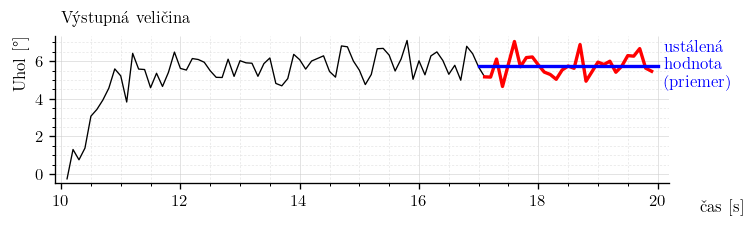

In [1383]:
figNamePrefix = MRSlabel + '_figsc_05_'
figNameNum = 5
exec(open('./figjobs/MRS06_figsc_05.py', encoding='utf-8').read())

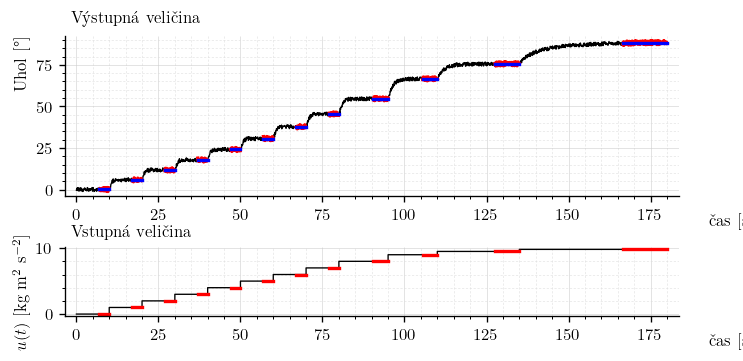

In [1384]:
figNamePrefix = MRSlabel + '_figsc_06_'
figNameNum = 6
exec(open('./figjobs/MRS06_figsc_06.py', encoding='utf-8').read())

In [1385]:
prevodChar = np.zeros([u_tabulka.shape[0] - 1, 2])

for idx in range(1, u_tabulka.shape[0]):

    ustVstup =  u_tabulka[idx-1][1]
    ustInterval = [u_tabulka[idx-1][0] + (u_tabulka[idx][0]-u_tabulka[idx-1][0])*0.7,
                   u_tabulka[idx][0]
                   ]

    boolMaska = np.logical_and(suroveData[:,0]>ustInterval[0], suroveData[:,0]<=ustInterval[1])

    ustVystCas = suroveData[boolMaska, 0]
    ustVystHodnoty = suroveData[boolMaska, 1]

    ustPriemer = np.mean(ustVystHodnoty)

    prevodChar[idx-1, 0] = ustVstup
    prevodChar[idx-1, 1] = ustPriemer



np.savetxt('./dataRepo/prevodChar.csv', prevodChar)
print(prevodChar)

[[0.00000000e+00 8.61437926e-02]
 [1.00000000e+00 5.75891352e+00]
 [2.00000000e+00 1.16311617e+01]
 [3.00000000e+00 1.77399236e+01]
 [4.00000000e+00 2.41043809e+01]
 [5.00000000e+00 3.06965675e+01]
 [6.00000000e+00 3.76250499e+01]
 [7.00000000e+00 4.53589824e+01]
 [8.00000000e+00 5.46674568e+01]
 [9.00000000e+00 6.65936537e+01]
 [9.50000000e+00 7.56254419e+01]
 [9.81000000e+00 8.82730005e+01]]


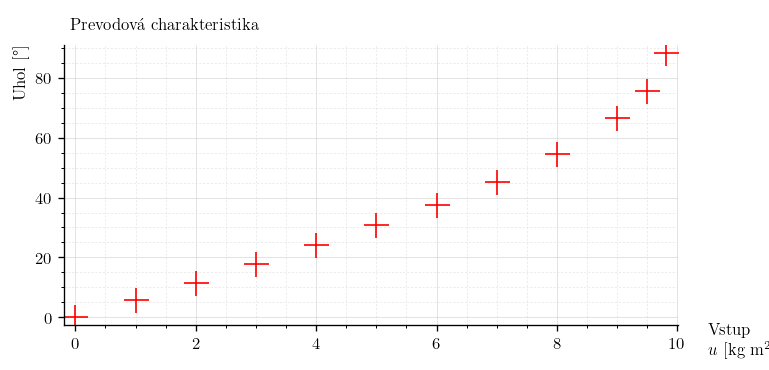

In [1386]:
figNamePrefix = MRSlabel + '_figsc_07_'
figNameNum = 7
exec(open('./figjobs/MRS06_figsc_07.py', encoding='utf-8').read())

### Doplnkový text: o aproximácii prevodovej charakteristiky lineárnym modelom

In [1387]:
prevodChar = np.loadtxt('./dataRepo/prevodChar.csv')

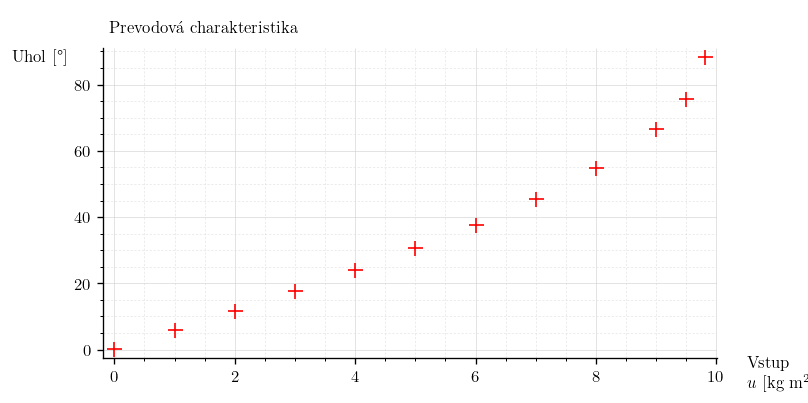

In [1388]:
figNamePrefix = MRSlabel + '_figsc_01_a_'
figNameNum = 1
exec(open('./figjobs/MRS06_figsc_01_a.py', encoding='utf-8').read())

In [1389]:
# pouzitie funkcie polyfit (z modulu numpy)

polyKoef = np.polyfit(prevodChar[:,0],prevodChar[:,1], 3)

print(polyKoef)

[ 0.10847813 -1.07509699  8.76243242 -1.12869421]


In [1390]:
# funkcia polyval pouzita pre vypocet aproximacie nameranych hodnot vystupu
y_hat = np.polyval(polyKoef, prevodChar[:,0])

print(y_hat)

[-1.12869421  6.66711935 12.96360771 18.41163965 23.66208395 29.3658094
 36.17368476 44.73657884 55.7053604  69.73089822 78.09334723 83.77924084]


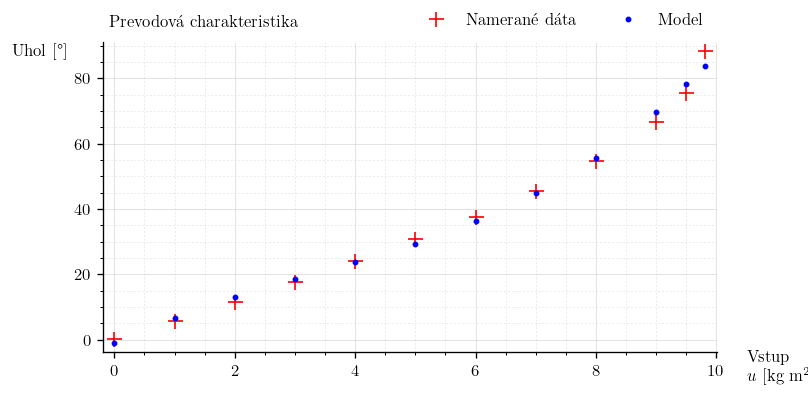

In [1391]:
figNamePrefix = MRSlabel + '_figsc_02_a_'
figNameNum = 2
exec(open('./figjobs/MRS06_figsc_02_a.py', encoding='utf-8').read())

In [1392]:
# vypocitanie aproximacie vystupu pre rozne vstupne hodnoty
u_ine = np.arange(0,9.81,0.1)
y_ine_1 = np.polyval(polyKoef, u_ine)

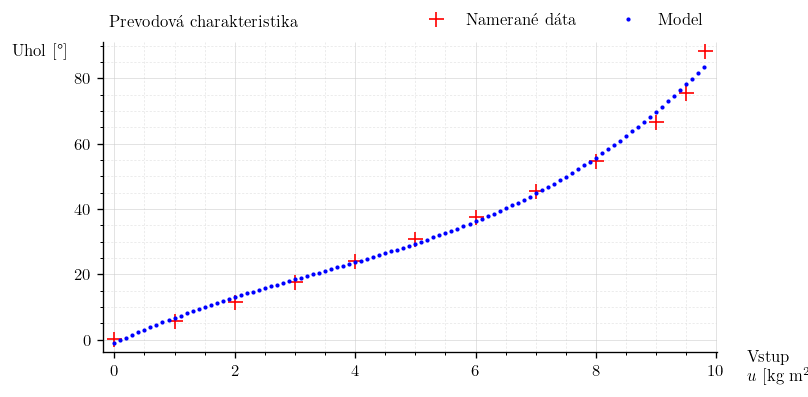

In [1393]:
figNamePrefix = MRSlabel + '_figsc_03_a_'
figNameNum = 3
exec(open('./figjobs/MRS06_figsc_03_a.py', encoding='utf-8').read())

In [1394]:
# zostavenie matice H a vektora y

H = np.hstack([
        (prevodChar[:,0].reshape(-1,1))**3,
        (prevodChar[:,0].reshape(-1,1))**2,
        prevodChar[:,0].reshape(-1,1),
        np.ones([prevodChar[:,0].shape[0],1]),
        ])

y = prevodChar[:,1].reshape(-1,1)

In [1395]:
# Riesenie preurceneho systemu rovnic v zmysle metody najmensich stvorcov
Theta = np.linalg.lstsq(H, y, rcond=None)[0]

np.savetxt('./dataRepo/theta_poly3order.csv', Theta)
print(Theta)

[[ 0.10847813]
 [-1.07509699]
 [ 8.76243242]
 [-1.12869421]]


In [1396]:
# Pouzitie Gaussovho vzorca
Theta_1 = np.matmul(np.matmul(np.linalg.inv(np.matmul(H.T, H)), H.T), y)

# %% ---------------------
print ('matica H je:\n')
print (H)

print ('\n')

print ('vektor y je:\n')
print (y)

print ('\n')

print ('vypocitane parametre \Theta su:\n')
print (Theta_1)

matica H je:

[[  0.         0.         0.         1.      ]
 [  1.         1.         1.         1.      ]
 [  8.         4.         2.         1.      ]
 [ 27.         9.         3.         1.      ]
 [ 64.        16.         4.         1.      ]
 [125.        25.         5.         1.      ]
 [216.        36.         6.         1.      ]
 [343.        49.         7.         1.      ]
 [512.        64.         8.         1.      ]
 [729.        81.         9.         1.      ]
 [857.375     90.25       9.5        1.      ]
 [944.076141  96.2361     9.81       1.      ]]


vektor y je:

[[8.61437926e-02]
 [5.75891352e+00]
 [1.16311617e+01]
 [1.77399236e+01]
 [2.41043809e+01]
 [3.06965675e+01]
 [3.76250499e+01]
 [4.53589824e+01]
 [5.46674568e+01]
 [6.65936537e+01]
 [7.56254419e+01]
 [8.82730005e+01]]


vypocitane parametre \Theta su:

[[ 0.10847813]
 [-1.07509699]
 [ 8.76243242]
 [-1.12869421]]


In [1397]:
y_model = np.matmul(H,Theta_1)

print ('vystup modelu pre dane (namerane) vstupy:\n')
print (y_model)

vystup modelu pre dane (namerane) vstupy:

[[-1.12869421]
 [ 6.66711935]
 [12.96360771]
 [18.41163965]
 [23.66208395]
 [29.3658094 ]
 [36.17368476]
 [44.73657884]
 [55.7053604 ]
 [69.73089822]
 [78.09334723]
 [83.77924084]]


### O meraní prechodovej charakteristiky

In [1398]:
prevodChar = np.loadtxt('./dataRepo/prevodChar.csv')

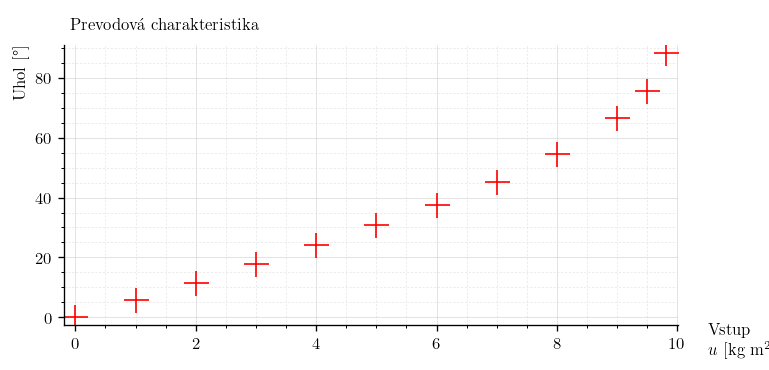

In [1399]:
figNamePrefix = MRSlabel + '_figsc_07_a_'
figNameNum = 666
exec(open('./figjobs/MRS06_figsc_07.py', encoding='utf-8').read())

In [1400]:
# pouzitie funkcie polyfit (z modulu numpy)

polyKoef = np.polyfit(prevodChar[:,0],prevodChar[:,1], 3)

print(polyKoef)

[ 0.10847813 -1.07509699  8.76243242 -1.12869421]


In [1401]:
# vypocitanie aproximacie vystupu pre rozne vstupne hodnoty
u_ine = np.arange(0,9.81,0.1)
y_ine_1 = np.polyval(polyKoef, u_ine)

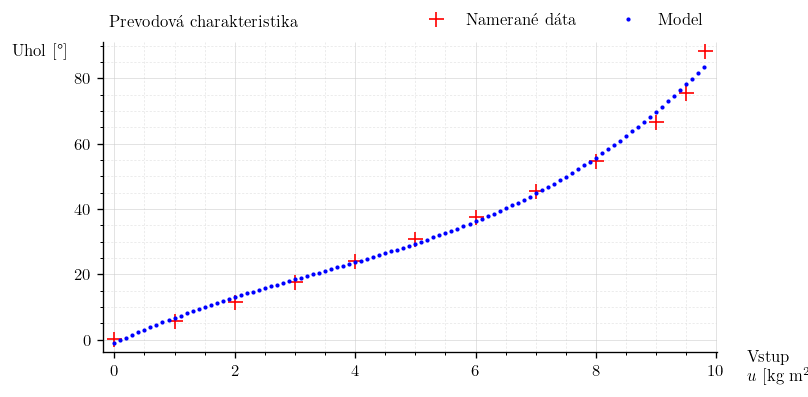

In [1402]:
figNamePrefix = MRSlabel + '_figsc_03_a_'
figNameNum = 666

exec(open('./figjobs/MRS06_figsc_03_a.py', encoding='utf-8').read())

In [1403]:
theta = polyKoef
theta = theta[-1::-1]

In [1404]:
u_PB1 = 4.0
y_PB1 =  theta[0] + theta[1] * u_PB1 + theta[2] * u_PB1**2 + theta[3] * u_PB1**3
print( u'y_PB1 = {:6.2f} [°]'.format(y_PB1))

y_PB1 =  23.66 [°]


In [1405]:
u_PB2 = 9.5
y_PB2 = theta[0] + theta[1] * u_PB2 + theta[2] * u_PB2**2 + theta[3] * u_PB2**3
print( u'y_PB2 = {:6.2f} [°]'.format(y_PB2))

y_PB2 =  78.09 [°]


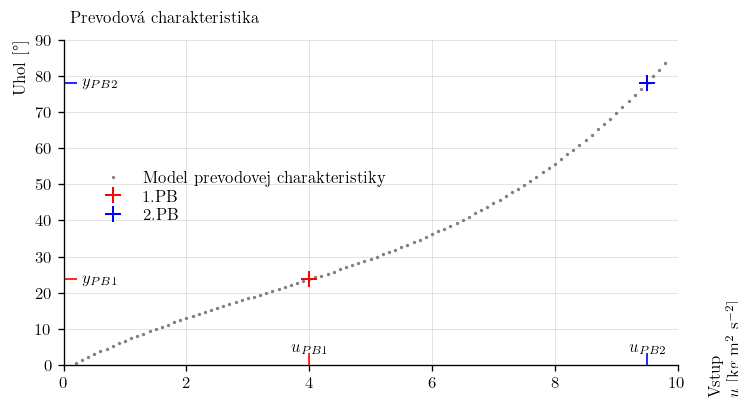

In [1406]:
figNamePrefix = MRSlabel + '_PCH_figsc_04_'
figNameNum = 0

exec(open('./figjobs/MRS06_PCH_figsc_04.py', encoding='utf-8').read())

In [1407]:
u_PB1_okol = 0.8

y_PB1_h = theta[0] + theta[1] * (u_PB1+u_PB1_okol) + theta[2] * (u_PB1+u_PB1_okol)**2 + theta[3] * (u_PB1+u_PB1_okol)**3
y_PB1_l = theta[0] + theta[1] * (u_PB1-u_PB1_okol) + theta[2] * (u_PB1-u_PB1_okol)**2 + theta[3] * (u_PB1-u_PB1_okol)**3

u_PB2_okol = 0.25

y_PB2_h = theta[0] + theta[1] * (u_PB2+u_PB2_okol) + theta[2] * (u_PB2+u_PB2_okol)**2 + theta[3] * (u_PB2+u_PB2_okol)**3
y_PB2_l = theta[0] + theta[1] * (u_PB2-u_PB2_okol) + theta[2] * (u_PB2-u_PB2_okol)**2 + theta[3] * (u_PB2-u_PB2_okol)**3

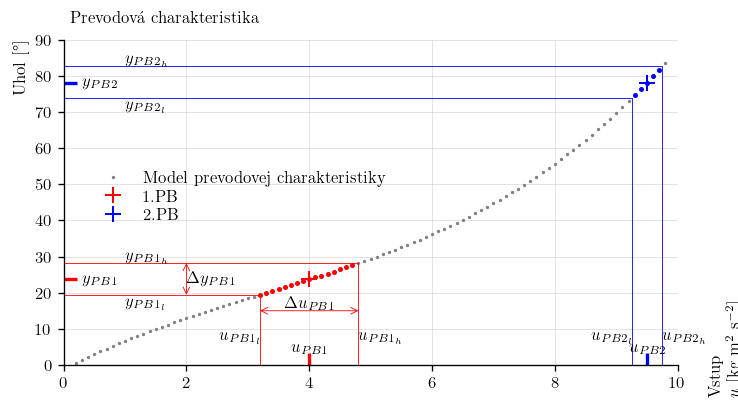

In [1408]:
figNamePrefix = MRSlabel + '_PCH_figsc_05_'
figNameNum = 0
exec(open('./figjobs/MRS06_PCH_figsc_05.py', encoding='utf-8').read())

In [1409]:
u_tabulka = np.array([
    [0, u_PB1],
    [10, u_PB1+u_PB1_okol],
    ])

In [1410]:
# Nastavenia simulacie

sim_t_start = 0
sim_t_final = 20
sim_T_s = 0.025
sim_finalIndex = int(((sim_t_final - sim_t_start)/sim_T_s) + 1)

# Simulacia
t_log, x_log, u_log, vystVelicina = fcn_simSch01(sim_t_start, sim_T_s, sim_finalIndex, u_tabulka)


C:\Users\MT\AppData\Local\Temp\ipykernel_15524\2456142686.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  timespan[0] = t_log[idx-1,:]
C:\Users\MT\AppData\Local\Temp\ipykernel_15524\2456142686.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  timespan[1] = t_log[idx-1,:] + T_s


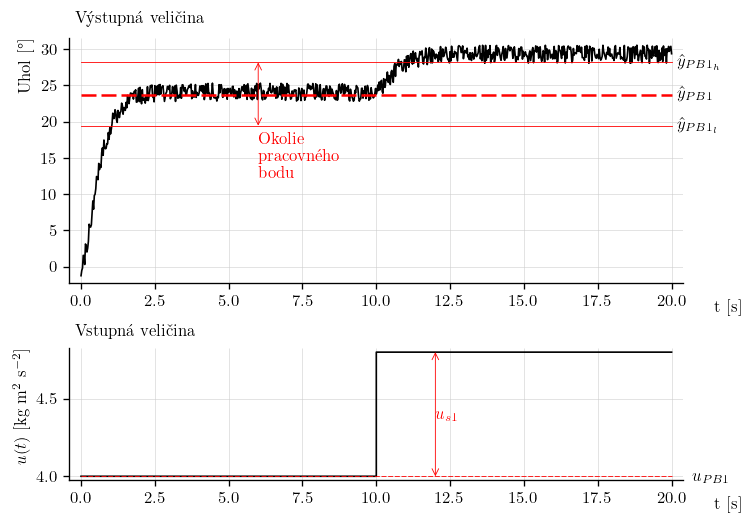

In [1423]:
figNamePrefix = MRSlabel + '_PCH_figsc_06_'
figNameNum = 0
exec(open('./figjobs/MRS06_PCH_figsc_06.py', encoding='utf-8').read())

In [1412]:
print( u'y_PB1 = {:6.2f} [°]'.format(y_PB1))

temp_Mask = np.logical_and((t_log < 10), (t_log>5))
y_PB1_data = np.mean(vystVelicina[temp_Mask])

print( u'y_PB1_data     = {:6.2f} [°]'.format(y_PB1_data))
print( u'y_PB1_odchylka = {:6.2f} [°]'.format(y_PB1_data - y_PB1) + u',   to je {:5.2f} [%]'.format(((y_PB1_data - y_PB1)/y_PB1)*100))



print( u'y_PB1_h     = {:6.2f} [°]'.format(y_PB1_h))

temp_Mask = np.logical_and((t_log <= 15), (t_log>12.5))
y_PB1_h_data = np.mean(vystVelicina[temp_Mask])

print( u'y_PB1_h_data     = {:6.2f} [°]'.format(y_PB1_h_data))

y_PB1 =  23.66 [°]
y_PB1_data     =  24.06 [°]
y_PB1_odchylka =   0.40 [°],   to je  1.70 [%]
y_PB1_h     =  28.16 [°]
y_PB1_h_data     =  29.41 [°]


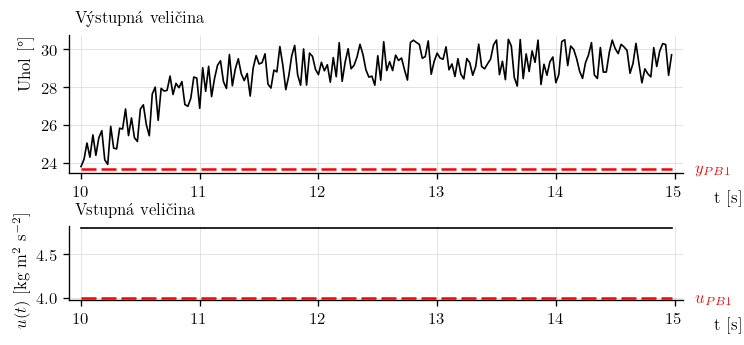

In [1430]:
temp_Mask = np.logical_and((t_log >= 10), (t_log <= 15))

surovaPCH_t = t_log[temp_Mask]
surovaPCH_y = vystVelicina[temp_Mask]
surovaPCH_u = u_log[temp_Mask]

figNamePrefix = MRSlabel + '_PCH_figsc_07_'
figNameNum = 0
exec(open('./figjobs/MRS06_PCH_figsc_07.py', encoding='utf-8').read())

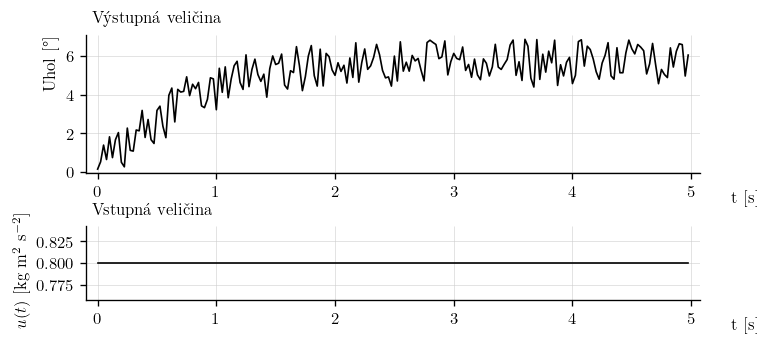

In [1433]:
posunutaPCH_t = surovaPCH_t - 10.0
posunutaPCH_y = surovaPCH_y - y_PB1
posunutaPCH_u = surovaPCH_u - u_PB1

figNamePrefix = MRSlabel + '_PCH_figsc_08_'
figNameNum = 0
exec(open('./figjobs/MRS06_PCH_figsc_08.py', encoding='utf-8').read())

In [1415]:
prechodChar = np.hstack([posunutaPCH_t.reshape(-1,1), posunutaPCH_y.reshape(-1,1), posunutaPCH_u.reshape(-1,1)])

np.savetxt('./dataRepo/prechodChar.csv', prechodChar)
np.savetxt('./dataRepo/zvolenePracovneBody.csv', [u_PB1, u_PB1_okol, u_PB2, u_PB2_okol])

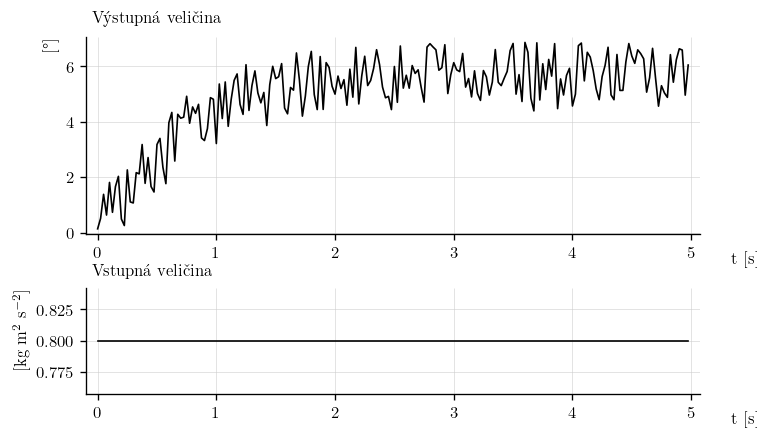

In [1416]:
prechodChar = np.loadtxt('./dataRepo/prechodChar.csv')

posunutaPCH_t = prechodChar[:,0]
posunutaPCH_y = prechodChar[:,1]
posunutaPCH_u = prechodChar[:,2]

figNamePrefix = MRSlabel + '_PCH_figsc_10_01_'
figNameNum = 0
exec(open('./figjobs/MRS06_PCH_figsc_10_01.py', encoding='utf-8').read())

In [1417]:
theta = np.loadtxt('./dataRepo/theta_poly3order.csv')

theta = theta[-1::-1]   # bude potrebne opacne poradie oproti tomu ako je to ulozene

u_PB1, u_PB1_okol, u_PB2, u_PB2_okol = np.loadtxt('./dataRepo/zvolenePracovneBody.csv')


y_PB1 =  theta[0] + theta[1] * u_PB1 + theta[2] * u_PB1**2 + theta[3] * u_PB1**3
y_PB1_h = theta[0] + theta[1] * (u_PB1+u_PB1_okol) + theta[2] * (u_PB1+u_PB1_okol)**2 + theta[3] * (u_PB1+u_PB1_okol)**3
y_PB1_l = theta[0] + theta[1] * (u_PB1-u_PB1_okol) + theta[2] * (u_PB1-u_PB1_okol)**2 + theta[3] * (u_PB1-u_PB1_okol)**3

print(y_PB1_h)

print(y_PB1_h - y_PB1)

28.157560113497645
4.495476162807336


Delta_y =   5.72 [°]
K =   7.15 [°/(kg m^2 s^-2)]


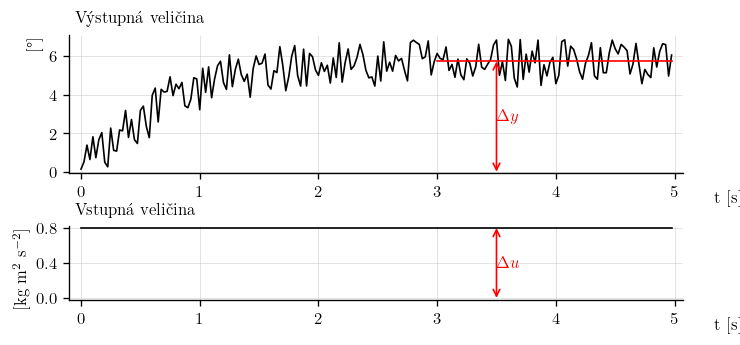

In [1434]:
temp_Mask = posunutaPCH_t >= 3.0
Delta_y = np.mean(posunutaPCH_y[temp_Mask])

print(u'Delta_y = {:6.2f} [°]'.format(Delta_y))

K = Delta_y/u_PB1_okol

print(u'K = {:6.2f} [°/(kg m^2 s^-2)]'.format(K))


figNamePrefix = MRSlabel + '_PCH_figsc_10_02_'
figNameNum = 0
exec(open('./figjobs/MRS06_PCH_figsc_10_02.py', encoding='utf-8').read())

Delta_y63 =   3.61  [°]
[0.525 0.6   0.775 0.875 0.9   0.925 1.1   1.425]
T =   0.89  [s]


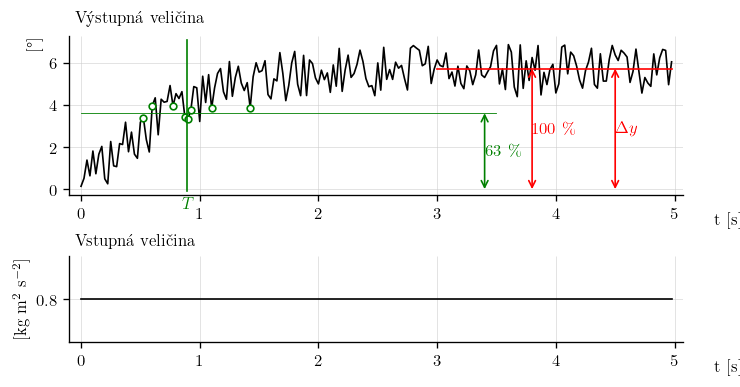

In [1437]:
Delta_y63 = Delta_y * 0.63
print(u'Delta_y63 = {:6.2f}'.format(Delta_y63) + u'  [°]')

temp_pct = 0.1
temp_Mask = np.logical_and( (posunutaPCH_y >= (Delta_y63-(Delta_y63*temp_pct))), (posunutaPCH_y <= (Delta_y63+(Delta_y63*temp_pct))))
print(posunutaPCH_t[temp_Mask])

T = np.mean(posunutaPCH_t[temp_Mask])
print(u'T = {:6.2f}'.format(T) + u'  [s]')


figNamePrefix = MRSlabel + '_PCH_figsc_10_03_'
figNameNum = 0
exec(open('./figjobs/MRS06_PCH_figsc_10_03.py', encoding='utf-8').read())

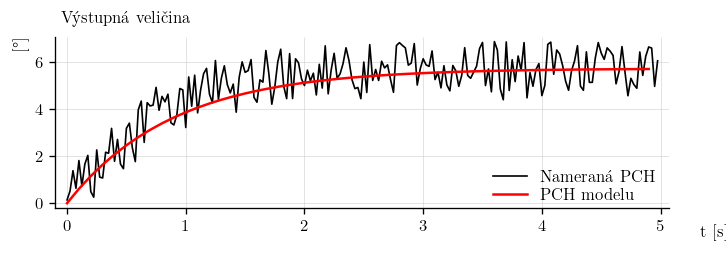

In [1441]:
def fcn_ss1r(x, t, u):

    dotx = -(1.0/T) * x + (K/T) * u

    return dotx



timeVect = np.arange(0, 5.0, 0.1)    

x = odeint(fcn_ss1r,
           [0],   # začiatočné podmienky
           timeVect,
           args=(u_PB1_okol,),
           )

figNamePrefix = MRSlabel + '_PCH_figsc_10_04_'
figNameNum = 0
exec(open('./figjobs/MRS06_PCH_figsc_10_04.py', encoding='utf-8').read())